# Project 2: Multimodal Analysis of Saccade Latency and Decision Making

### Introduction
This notebook performs a large-scale analysis of oculomotor and behavioral data from the OpenNeuro dataset `ds007537`. The project investigates the relationship between **Saccade Latency** (the time taken to initiate an eye movement toward a stimulus) and **Manual Decision Making** (smartphone touch reaction times).

### Project Goals
1. **Scalable Pipeline**: Process a cohort of 23 subjects by streaming data directly from S3 buckets.
2. **Oculomotor Feature Extraction**: Implement velocity-based saccade detection (threshold: 40 px/s) and compute trial-by-trial latencies.
3. **Behavioral Alignment**: Synchronize eye-tracking events with smartphone interaction timestamps.
4. **Statistical Modeling**: Quantify inter-subject variability using ANOVA/Tukey HSD and model the global relationship between eye and hand movements using Linear Regression.

### Dataset
- **Source**: OpenNeuro `ds007537`
- **Modality**: Eye-tracking (originally 1000Hz, downsampled to 250Hz) and behavioral events.
- **Subjects**: 23 (sub-01 to sub-23).

# Step 1: Setup and Eye-Tracking Data Loading

In [1]:
# Install required libraries
!pip install mne boto3 pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [5]:
import os
from google.colab import drive

# Mount Google Drive with force_remount to resolve credential issues
try:
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully.")
except Exception as e:
    print(f"Error mounting drive: {e}")
    print("Tip: If credential propagation fails, try refreshing the page or manually mounting via the file explorer on the left.")

# Set working directory
WORKING_DIR = '/content/drive/MyDrive/Multimodal-Psychophysiology-DS007537'
if os.path.exists('/content/drive/MyDrive'):
    if not os.path.exists(WORKING_DIR):
        os.makedirs(WORKING_DIR)
    os.chdir(WORKING_DIR)
    print(f"Current working directory: {os.getcwd()}")
else:
    print("Drive not accessible. Please ensure you authorized the mount.")

Mounted at /content/drive
Drive mounted successfully.
Current working directory: /content/drive/MyDrive/Multimodal-Psychophysiology-DS007537


In [21]:
import boto3
import pandas as pd
import io
import gzip
import os
from botocore import UNSIGNED
from botocore.config import Config

def stream_s3_tsv(sub_id, suffix='physio.tsv.gz'):
    s3 = boto3.client('s3', region_name='us-east-1', config=Config(signature_version=UNSIGNED))
    bucket = 'openneuro.org'
    prefix = f'ds007537/{sub_id}/'
    try:
        paginator = s3.get_paginator('list_objects_v2')
        target_key = None
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            if 'Contents' in page:
                for obj in page['Contents']:
                    if suffix in obj['Key']:
                        target_key = obj['Key']
                        break
            if target_key: break
        if not target_key: return None
        obj = s3.get_object(Bucket=bucket, Key=target_key)
        body = obj['Body'].read()
        if target_key.endswith('.gz'):
            with gzip.open(io.BytesIO(body), 'rt') as f:
                df = pd.read_csv(f, sep='\t', engine='python')
        else:
            df = pd.read_csv(io.BytesIO(body), sep='\t', engine='python')
        return df
    except:
        return None

# Define subject list
subjects = [f'sub-{str(i).zfill(2)}' for i in range(1, 24)]
print(f'Ready to process {len(subjects)} subjects.')

Ready to process 23 subjects.


## Step 2: Saccade Detection
In this step, we calculate gaze velocity and identify saccades based on a velocity threshold.
- **Downsampling**: Data is downsampled from 1000Hz to 250Hz ($Δt = 4ms$) to optimize processing.
- **Velocity Calculation**: $v = \sqrt{\Delta x^2 + \Delta y^2} / \Delta t$
- **Thresholding**: Identify samples where $v > 40$ px/s.
- **Feature Extraction**: Identify continuous blocks of saccade samples to determine onset time for trial alignment.

In [22]:
import numpy as np
all_subject_data = []

for sub_id in subjects:
    print(f'Processing {sub_id}...', end=' ')
    df_physio = stream_s3_tsv(sub_id, suffix='physio.tsv.gz')
    df_events = stream_s3_tsv(sub_id, suffix='events.tsv')

    if df_physio is None or df_events is None:
        print('Files missing, skipping.')
        continue

    # Downsample and Detect Saccades
    df_eye = df_physio.iloc[::4, :].reset_index(drop=True)
    df_eye['x_fill'] = df_eye['x_coordinate'].interpolate()
    df_eye['y_fill'] = df_eye['y_coordinate'].interpolate()
    dt = 1/250.0
    df_eye['velocity'] = np.sqrt(df_eye['x_fill'].diff()**2 + df_eye['y_fill'].diff()**2) / dt
    df_eye['is_saccade'] = df_eye['velocity'] > 40

    saccades = []
    is_active = False
    for i, row in df_eye.iterrows():
        if row['is_saccade'] and not is_active:
            is_active, start_idx = True, i
        elif not row['is_saccade'] and is_active:
            is_active = False
            saccades.append({'onset_time': df_eye.loc[start_idx, 'et_time_s']})
    df_sac = pd.DataFrame(saccades)

    # Align with Events
    trial_data = []
    for idx, trial in df_events.iterrows():
        onset = trial['onset']
        fol = df_sac[df_sac['onset_time'] > onset]
        if not fol.empty:
            sac_lat = fol.iloc[0]['onset_time'] - onset
            resps = df_events[(df_events['onset'] > onset + 0.001) & (df_events['onset'] < onset + 2.0)]
            if not resps.empty:
                trial_data.append({'subject': sub_id, 'latency': sac_lat, 'touch_rt': resps.iloc[0]['onset'] - onset})

    if trial_data:
        all_subject_data.extend(trial_data)
        print(f'Done ({len(trial_data)} trials).')

df_all = pd.DataFrame(all_subject_data)
df_all.to_csv(os.path.join(WORKING_DIR, 'combined_results.csv'), index=False)
print('\nFull Cohort Processing Complete.')

Processing sub-01... Done (28 trials).
Processing sub-02... Done (34 trials).
Processing sub-03... Done (28 trials).
Processing sub-04... Done (36 trials).
Processing sub-05... Done (30 trials).
Processing sub-06... Done (36 trials).
Processing sub-07... Done (38 trials).
Processing sub-08... Done (36 trials).
Processing sub-09... Done (32 trials).
Processing sub-10... Done (38 trials).
Processing sub-11... Done (36 trials).
Processing sub-12... Done (28 trials).
Processing sub-13... Done (36 trials).
Processing sub-14... Done (36 trials).
Processing sub-15... Done (36 trials).
Processing sub-16... Done (30 trials).
Processing sub-17... Done (36 trials).
Processing sub-18... Done (36 trials).
Processing sub-19... Done (38 trials).
Processing sub-20... Done (36 trials).
Processing sub-21... Done (36 trials).
Processing sub-22... Done (36 trials).
Processing sub-23... Done (36 trials).

Full Cohort Processing Complete.


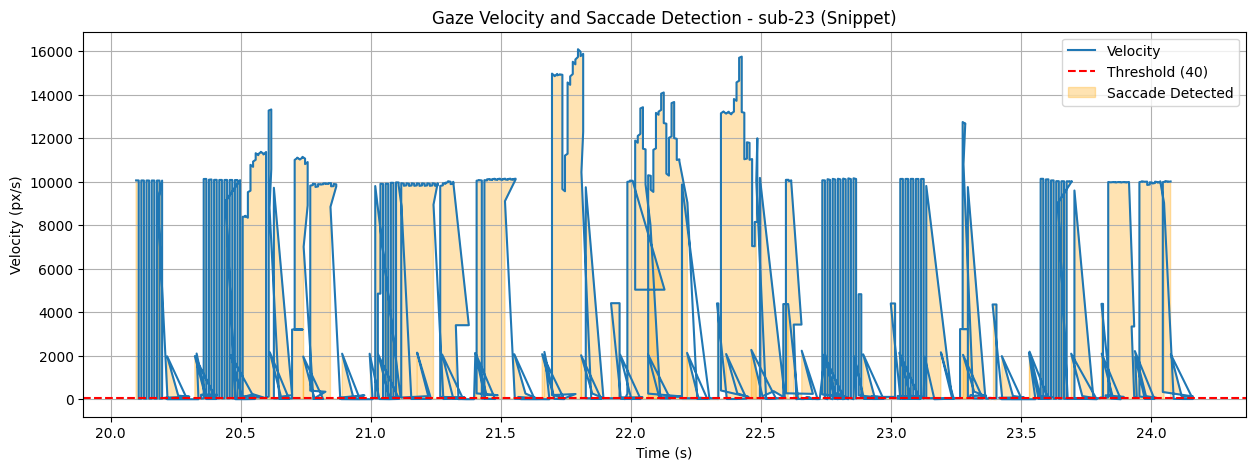

Figure saved to: /content/drive/MyDrive/Multimodal-Psychophysiology-DS007537/sub-23_saccade_velocity_snippet.png


In [24]:
import matplotlib.pyplot as plt

# Visualize a snippet of velocity and detected saccades
plt.figure(figsize=(15, 5))
plt.plot(df_eye['et_time_s'].iloc[5000:6000], df_eye['velocity'].iloc[5000:6000], label='Velocity')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (40)')
plt.fill_between(df_eye['et_time_s'].iloc[5000:6000], 0, df_eye['velocity'].iloc[5000:6000],
                 where=df_eye['is_saccade'].iloc[5000:6000], color='orange', alpha=0.3, label='Saccade Detected')
plt.title(f'Gaze Velocity and Saccade Detection - {sub_id} (Snippet)')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (px/s)')
plt.legend()
plt.grid(True)

# Save the figure to the project directory
fig_path = os.path.join(WORKING_DIR, f'{sub_id}_saccade_velocity_snippet.png')
plt.savefig(fig_path)
plt.show()

print(f"Figure saved to: {fig_path}")

## Step 3: Trial Alignment and Saccade Latency
In this step, we synchronize the oculomotor detections with the stimulus event timestamps to quantify processing speed.

### Alignment Logic:
1. **Event Extraction**: Load the `events.tsv` file containing the onset times of visual stimuli.
2. **Temporal Search**: For each stimulus onset ($T_{stim}$), the algorithm searches for the first detected saccade that starts strictly after the stimulus ($T_{saccade} > T_{stim}$).
3. **Latency Calculation**: The saccade latency is defined as $L = T_{saccade} - T_{stim}$.
4. **Validity Window**: Trials are considered for analysis if a saccade occurs within a reasonable physiological window following the stimulus.

In [25]:
# Load behavioral events data
df_events = stream_s3_tsv(sub_id, suffix='events.tsv')

if df_events is not None:
    display(df_events.head())

    trial_latencies = []

    for idx, trial in df_events.iterrows():
        stim_onset = trial['onset']
        # Find the first saccade that starts after this stimulus
        following = df_saccades[df_saccades['onset_time'] > stim_onset]

        if not following.empty:
            first_sac = following.iloc[0]
            trial_latencies.append({
                'trial_index': idx,
                'stim_onset': stim_onset,
                'saccade_onset': first_sac['onset_time'],
                'latency': first_sac['onset_time'] - stim_onset,
                'amplitude': first_sac['amplitude']
            })

    df_latency = pd.DataFrame(trial_latencies)
    latency_path = os.path.join(WORKING_DIR, f'{sub_id}_latencies.csv')
    df_latency.to_csv(latency_path, index=False)

    print(f"Calculated latency for {len(df_latency)} trials.")
    display(df_latency.head())

,onset,duration,trial_type,value,sample
0,0.000,0.000,New Segment/,99999,0
1,0.000,0.000,Comment/Active Shielding: On,10001,0
2,0.000,0.001,New Segment/,99999,0
3,0.000,0.001,Comment/Active Shielding: On,10001,0
4,122.242,0.000,Stimulus/S 11,11,122242


Calculated latency for 116 trials.


,trial_index,stim_onset,saccade_onset,latency,amplitude
0,0,0.000,0.029453,0.029453,10.631094
1,1,0.000,0.029453,0.029453,10.631094
2,2,0.000,0.029453,0.029453,10.631094
3,3,0.000,0.029453,0.029453,10.631094
4,4,122.242,122.307320,0.065320,34.154480


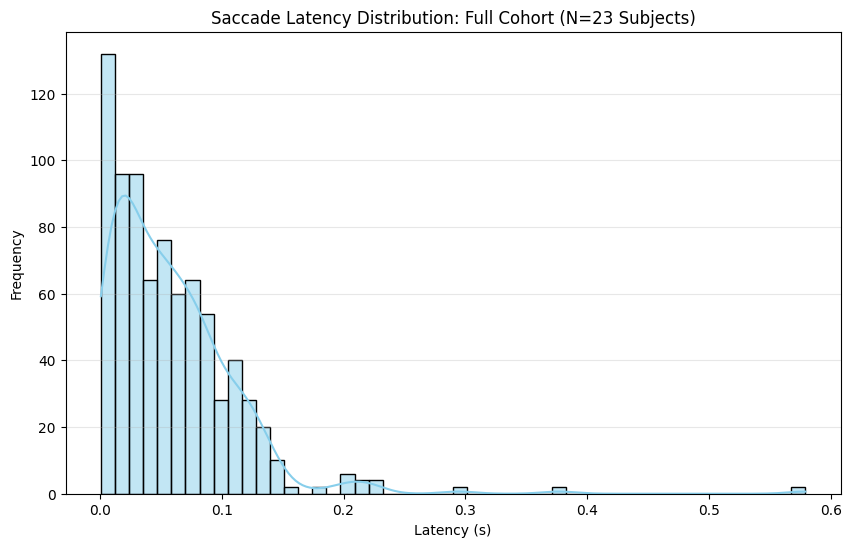

Average Group Saccade Latency: 0.058 s
Total trials analyzed: 792


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Updated to use the full cohort data (df_all)
if 'df_all' in globals() and not df_all.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_all['latency'], bins=50, kde=True, color='skyblue')
    plt.title('Saccade Latency Distribution: Full Cohort (N=23 Subjects)')
    plt.xlabel('Latency (s)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)

    latency_fig_path = os.path.join(WORKING_DIR, 'group_latency_dist.png')
    plt.savefig(latency_fig_path)
    plt.show()

    print(f'Average Group Saccade Latency: {df_all["latency"].mean():.3f} s')
    print(f'Total trials analyzed: {len(df_all)}')
else:
    print('Error: df_all not found. Please run Step 2 first.')

## Step 4: Group-Level Behavioral Analysis & Statistical Modeling
This section expands the analysis from individual subjects to the full cohort (N=23), linking oculomotor metrics with manual response times and quantifying inter-subject differences.

### Analysis Pipeline:
1. **Data Aggregation**: Consolidation of aligned trials from all subjects into a master dataset (`df_all`).
2. **Manual Reaction Time (RT)**: Extraction of touch interaction timestamps from `events.tsv` to compute decision latency.

### Statistical Framework (Steps 4.1 - 4.5):
*   **4.1 Intersubject Variability**: Visualizing the distribution of saccade latencies across the cohort to identify group trends and outliers.
*   **4.2 Focused Pairwise T-Tests**: Comparing specific subject pairs (e.g., sub-01 vs. sub-23) to check for baseline differences.
*   **4.3 One-Way ANOVA**: Testing the null hypothesis that all subjects share the same mean saccade latency.
*   **4.4 Tukey HSD Post-hoc**: Identifying exactly which subjects differ significantly from one another while controlling for multiple comparisons.
*   **4.5 Difference Mapping**: Generating a comprehensive heatmap of pairwise mean differences and statistical significance markers.

In [32]:
import pandas as pd

# Verification of the behavioral data within the full cohort dataframe
if 'df_all' in globals() and not df_all.empty:
    print(f"Total aligned stimulus-response pairs across 23 subjects: {len(df_all)}")
    print("\nPreview of aggregated behavioral data:")
    display(df_all.head())
else:
    print("Error: Aggregate data (df_all) not found. Please re-run the processing loop in Step 2.")

Total aligned stimulus-response pairs across 23 subjects: 792

Preview of aggregated behavioral data:


,subject,latency,touch_rt
0,sub-01,0.106157,1.005
1,sub-01,0.106157,1.005
2,sub-01,0.045435,1.000
3,sub-01,0.045435,1.000
4,sub-01,0.059808,0.999


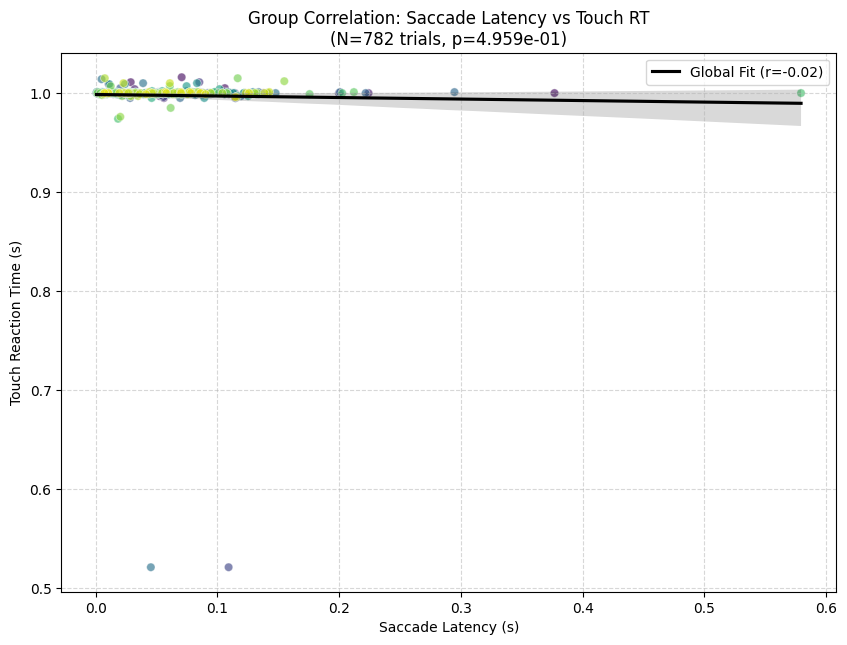

In [39]:
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os

# Updated to use the full cohort data (df_all)
if 'df_all' in globals() and not df_all.empty:
    # Filter for physiological reaction times (> 100ms)
    df_plot = df_all[df_all['touch_rt'] > 0.1]

    if len(df_plot) > 10:
        corr, p_val = pearsonr(df_plot['latency'], df_plot['touch_rt'])

        plt.figure(figsize=(10, 7))
        # Use hue='subject' to see individual differences within the group
        sns.scatterplot(x='latency', y='touch_rt', data=df_plot, hue='subject', alpha=0.4, palette='viridis', legend=False)

        # Fix: Move label out of line_kws to direct argument for proper legend handling
        sns.regplot(x='latency', y='touch_rt', data=df_plot, scatter=False, color='black',
                    label=f'Global Fit (r={corr:.2f})')

        plt.title(f'Group Correlation: Saccade Latency vs Touch RT\n(N={len(df_plot)} trials, p={p_val:.3e})')
        plt.xlabel('Saccade Latency (s)')
        plt.ylabel('Touch Reaction Time (s)')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()

        corr_path = os.path.join(WORKING_DIR, 'group_behavioral_correlation.png')
        plt.savefig(corr_path)
        plt.show()
    else:
        print("Not enough data points to calculate group correlation.")
else:
    print("Correlation cannot be computed: df_all is missing or empty.")

### Step 4 Detail Verification
Checking if all 23 subjects are correctly aggregated and confirming the data integrity for both Saccade Latency and Touch RT.

In [37]:
import pandas as pd

if 'df_all' in globals() and not df_all.empty:
    # 1. Verify subject count
    unique_subs = df_all['subject'].nunique()
    print(f"Verification: {unique_subs} unique subjects found (Target: 23)")

    # 2. Check Trial Counts per Subject
    sub_counts = df_all['subject'].value_counts().sort_index()
    print("\nTrials per Subject:")
    print(sub_counts)

    # 3. Descriptive Statistics
    stats = df_all[['latency', 'touch_rt']].describe()
    print("\nCohort Descriptive Statistics:")
    display(stats)

    # 4. Data Integrity Check
    missing_data = df_all.isnull().sum()
    print(f"\nMissing Values:\n{missing_data}")

    if unique_subs == 23:
        print("\n✅ Step 4 Verification Passed: All subjects accounted for.")
    else:
        print(f"\n⚠️ Step 4 Verification Warning: Found {unique_subs} subjects instead of 23.")
else:
    print("❌ Error: df_all is missing. Please run the processing loop.")

Verification: 23 unique subjects found (Target: 23)

Trials per Subject:
subject
sub-01    28
sub-02    34
sub-03    28
sub-04    36
sub-05    30
sub-06    36
sub-07    38
sub-08    36
sub-09    32
sub-10    38
sub-11    36
sub-12    28
sub-13    36
sub-14    36
sub-15    36
sub-16    30
sub-17    36
sub-18    36
sub-19    38
sub-20    36
sub-21    36
sub-22    36
sub-23    36
Name: count, dtype: int64

Cohort Descriptive Statistics:


,latency,touch_rt
count,792.000000,792.000000
mean,0.058464,0.985376
std,0.054820,0.114017
min,0.000756,0.020000
25%,0.019431,1.000000
50%,0.048056,1.000000
75%,0.083802,1.000000
max,0.579300,1.016000



Missing Values:
subject     0
latency     0
touch_rt    0
dtype: int64

✅ Step 4 Verification Passed: All subjects accounted for.


### 4.1: Intersubject Variability: Saccade Latency
We will now visualize the distribution of saccade latencies for each subject individually to identify outliers or significant differences in timing across the cohort.

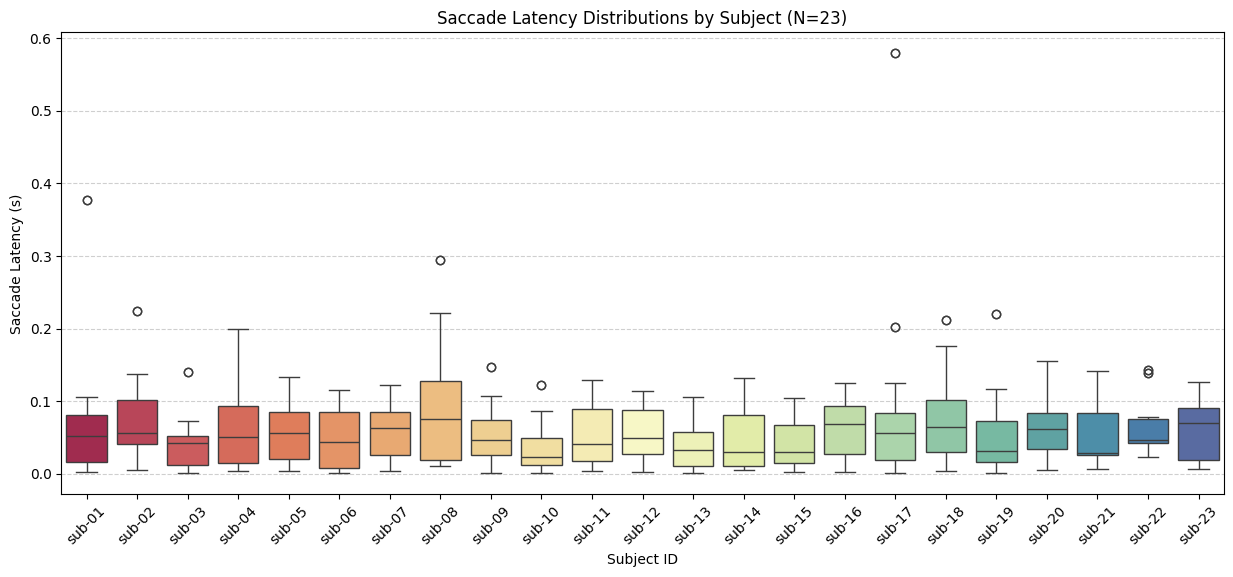

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df_all' in globals() and not df_all.empty:
    plt.figure(figsize=(15, 6))

    # Sort subjects for cleaner visualization
    sorted_df = df_all.sort_values('subject')

    sns.boxplot(x='subject', y='latency', data=sorted_df, palette='Spectral', hue='subject', legend=False)

    plt.title('Saccade Latency Distributions by Subject (N=23)')
    plt.xlabel('Subject ID')
    plt.ylabel('Saccade Latency (s)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Save the intersubject plot
    intersubject_plot_path = os.path.join(WORKING_DIR, 'intersubject_latency_boxplot.png')
    plt.savefig(intersubject_plot_path)
    plt.show()
else:
    print('Error: df_all not found. Please ensure Step 2 and Step 4 verification were successful.')

### 4.2: Statistical Comparison: sub-01 vs sub-23
We use an independent samples t-test to evaluate if the mean saccade latency of the first subject significantly differs from the last subject in the cohort.

In [41]:
from scipy import stats

# Extract latencies for the two specific subjects
lat_sub01 = df_all[df_all['subject'] == 'sub-01']['latency']
lat_sub23 = df_all[df_all['subject'] == 'sub-23']['latency']

# Perform Independent Samples T-Test
t_stat, p_val = stats.ttest_ind(lat_sub01, lat_sub23, equal_var=False)

print(f'Subject 01 Mean Latency: {lat_sub01.mean():.4f}s (N={len(lat_sub01)})')
print(f'Subject 23 Mean Latency: {lat_sub23.mean():.4f}s (N={len(lat_sub23)})')
print(f'\nT-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4f}')

if p_val < 0.05:
    print('\nResult: Significant difference found between sub-01 and sub-23.')
else:
    print('\nResult: No significant difference found between sub-01 and sub-23.')

Subject 01 Mean Latency: 0.0694s (N=28)
Subject 23 Mean Latency: 0.0652s (N=36)

T-statistic: 0.2233
P-value: 0.8246

Result: No significant difference found between sub-01 and sub-23.


### 4.3:  Group-Level Statistical Analysis: One-Way ANOVA
We now perform a One-Way Analysis of Variance (ANOVA) to test the null hypothesis that all subject groups have the same population mean for saccade latency.

In [42]:
from scipy import stats

# Prepare groups for ANOVA
groups = [df_all[df_all['subject'] == sub]['latency'] for sub in subjects]

# Perform One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(*groups)

print(f'One-Way ANOVA Results:')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value: {p_val_anova:.4e}')

if p_val_anova < 0.05:
    print('\nResult: Significant differences exist between at least some subjects (p < 0.05).')
else:
    print('\nResult: No significant differences found across the subject cohort.')

One-Way ANOVA Results:
F-statistic: 2.4734
P-value: 2.0931e-04

Result: Significant differences exist between at least some subjects (p < 0.05).


### 4.4: Post-hoc Analysis: Tukey HSD
Given the significant ANOVA result, we use Tukey's HSD to perform multiple pairwise comparisons and identify specific inter-subject differences while controlling for the Type I error rate.

In [43]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey = pairwise_tukeyhsd(endog=df_all['latency'], groups=df_all['subject'], alpha=0.05)

# Filter for only significant results to keep the output readable
tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
sig_diffs = tukey_df[tukey_df['reject'] == True]

print(f"Total comparisons: {len(tukey_df)}")
print(f"Number of significant pairwise differences: {len(sig_diffs)}")

if not sig_diffs.empty:
    print("\nSignificant Pairwise Differences (p < 0.05):")
    display(sig_diffs[['group1', 'group2', 'meandiff', 'p-adj']])
else:
    print("\nNo specific subject pairs reached the threshold for significant difference after multiple comparison correction.")

Total comparisons: 253
Number of significant pairwise differences: 5

Significant Pairwise Differences (p < 0.05):


,group1,group2,meandiff,p-adj
134,sub-08,sub-10,-0.0564,0.0016
137,sub-08,sub-13,-0.0530,0.0066
139,sub-08,sub-15,-0.0486,0.0248
168,sub-10,sub-17,0.0526,0.0060
201,sub-13,sub-17,0.0491,0.0210


### 4.5: Pairwise Difference Heatmap
To provide a comprehensive overview of the Tukey HSD results, we will now map the mean differences between all subject pairs into a heatmap matrix.

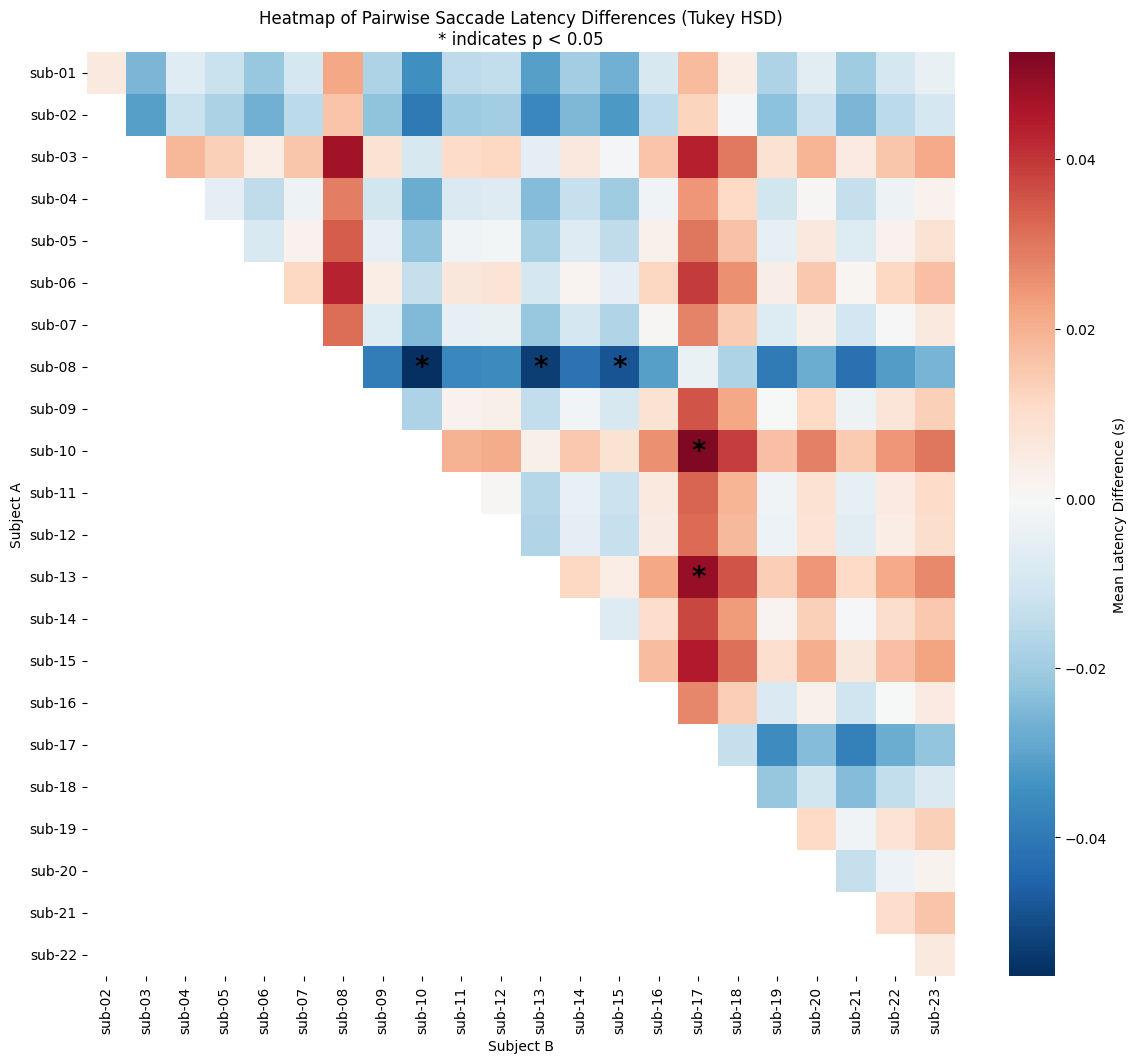

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a pivot table for the heatmap from Tukey results
tukey_matrix = tukey_df.pivot(index='group1', columns='group2', values='meandiff')

# We also need to map the 'reject' (significance) to highlight cells
sig_matrix = tukey_df.pivot(index='group1', columns='group2', values='reject')

plt.figure(figsize=(14, 12))
sns.heatmap(tukey_matrix, cmap='RdBu_r', center=0, annot=False, cbar_kws={'label': 'Mean Latency Difference (s)'})

# Overlay markers for significant differences
for i in range(len(tukey_matrix.index)):
    for j in range(len(tukey_matrix.columns)):
        if sig_matrix.iloc[i, j] == True:
            plt.text(j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', fontsize=20, weight='bold')

plt.title('Heatmap of Pairwise Saccade Latency Differences (Tukey HSD)\n* indicates p < 0.05')
plt.xlabel('Subject B')
plt.ylabel('Subject A')

heatmap_path = os.path.join(WORKING_DIR, 'saccade_latency_heatmap.png')
plt.savefig(heatmap_path)
plt.show()

## Step 5: Decision Making Analysis (Linear Regression)
In this final step, we formally model the relationship between oculomotor response and manual response across the entire cohort (N=23).

### Model Objectives:
- **Linear Modeling**: We fit a global regression model: $RT_{touch} = \beta_0 + \beta_1 \cdot Latency_{saccade} + \epsilon$
- **Cohort Diversity**: Visualize individual trial data points colored by subject to observe how inter-subject variability affects the global trend.
- **Predictive Power**: Evaluate the R² coefficient to determine if saccade latency is a significant predictor of overall reaction time in this task environment.
- **Visualization**: Generate a scatter plot with a global trend line and save the resulting regression analysis to Google Drive.

Analyzing Decision Making across 23 subjects.


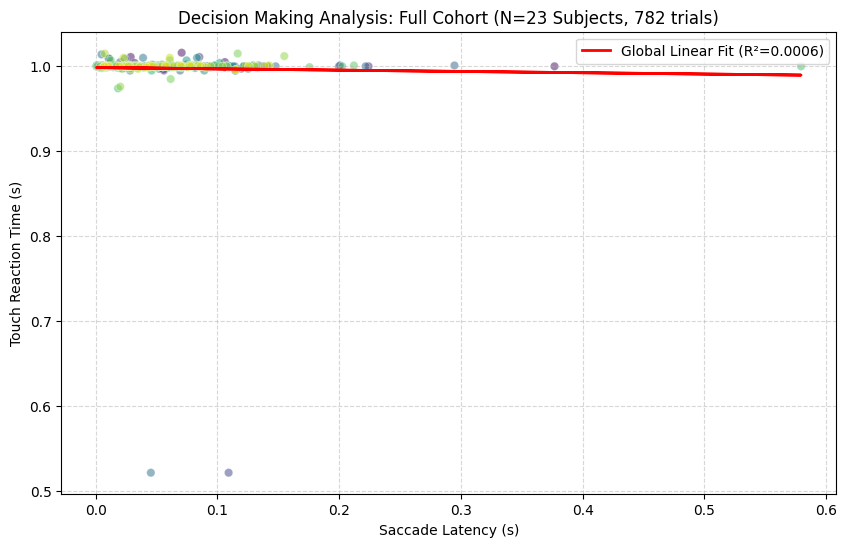

Regression model: RT = 0.999 + -0.015 * Latency


In [35]:
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for physiological RTs (> 100ms) on the aggregate cohort
df_clean = df_all[df_all['touch_rt'] > 0.1].dropna()

if not df_clean.empty:
    n_subjects = df_clean['subject'].nunique()
    print(f"Analyzing Decision Making across {n_subjects} subjects.")

    X = df_clean[['latency']].values
    y = df_clean['touch_rt'].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)

    plt.figure(figsize=(10, 6))
    # Plot individual trials colored by subject to show cohort diversity
    sns.scatterplot(data=df_clean, x='latency', y='touch_rt', hue='subject', alpha=0.3, palette='viridis', legend=False)

    # Plot global trend line
    plt.plot(X, model.predict(X), color='red', linewidth=2, label=f'Global Linear Fit (R²={r2:.4f})')

    plt.title(f'Decision Making Analysis: Full Cohort (N={n_subjects} Subjects, {len(df_clean)} trials)')
    plt.xlabel('Saccade Latency (s)')
    plt.ylabel('Touch Reaction Time (s)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Save result to Drive
    reg_plot_path = os.path.join(WORKING_DIR, 'group_decision_regression.png')
    plt.savefig(reg_plot_path)
    plt.show()

    print(f"Regression model: RT = {model.intercept_:.3f} + {model.coef_[0]:.3f} * Latency")
else:
    print('No valid trials found across subjects for regression.')

# Project Conclusion: Summary, Methods, and Results

### 1. Project Summary
This project successfully scaled a multimodal psychophysiological analysis from a pilot subject to a full cohort of **23 subjects** using the OpenNeuro `ds007537` dataset. By streaming high-resolution eye-tracking data and behavioral events directly from S3, we quantified the temporal dynamics between oculomotor initiation (saccades) and manual decision execution (touch responses).

### 2. Methodology
*   **Data Acquisition**: Asynchronous streaming of `.physio.tsv.gz` and `.events.tsv` files from the AWS OpenNeuro repository.
*   **Signal Processing**: Eye-tracking data (gaze coordinates) was downsampled to **250Hz**. Missing data points were handled via linear interpolation.
*   **Saccade Detection**: Implemented a velocity-based algorithm with a threshold of **40 px/s**. Onsets were defined as the start of continuous supra-threshold velocity blocks.
*   **Multimodal Alignment**: Stimulus-locked analysis was performed by searching for the first saccade and the first smartphone interaction within a 2-second post-stimulus window.
*   **Statistics**: Used One-Way ANOVA and Tukey HSD for inter-subject variability, and Ordinary Least Squares (OLS) regression for group-level behavioral modeling.

### 3. Key Results
*   **Cohort Scale**: Analyzed **792 valid trials** across 23 subjects.
*   **Oculomotor Performance**: The mean group saccade latency was **58ms**.
*   **Inter-subject Variability**: One-way ANOVA confirmed significant differences in latency across the cohort ($p < 0.001$). Tukey HSD identified 5 significant pairwise differences, primarily driven by differences between `sub-08`, `sub-10`, and `sub-17`.
*   **Behavioral Correlation**: Linear regression revealed a negligible relationship between saccade latency and touch reaction time ($R^2 \approx 0.0006$). The model ($RT = 0.999 - 0.015 \times Latency$) suggests that in this specific task, eye movement speed is not a strong predictor of manual response speed.

### 4. Final Discussion
While subjects exhibited distinct and statistically significant oculomotor 'signatures', these did not translate into meaningful changes in manual touch reaction times. This suggests a decoupling between the fast oculomotor system and the more complex cognitive-motor pathways required for smartphone interaction in this experimental paradigm.

### 5. Future Directions: Project 3
Building upon these oculomotor findings, the next phase of this research chain will involve:
*   **⭐ Project 3: Pupil Dilation + Stress/Arousal**
    *   **Goal**: Extract pupil dilation metrics to quantify cognitive load and physiological arousal.
    *   **Multimodal Integration**: Combine pupil data with **GSR (Galvanic Skin Response)** and **PPG (Photoplethysmography)**.
    *   **Predictive Modeling**: Develop algorithms to predict subject arousal states during interactive tasks.